# 🏦 Holistic Data Preparer — Final Project
## Customer Credit Risk Dataset: Complete Data Preprocessing & Feature Engineering Pipeline
**Duration:** 8 Days (1 hour/day) | **Role:** Junior Data Scientist @ FinTech

---
**Parts Covered:** A (Conceptual) → B (Acquisition) → C (Cleaning) → D (Outlier) → E (Feature Eng.) → F (Scaling) → G (Transformation) → H (Deliverable)

---
## 📘 Part A: Conceptual Foundation

### 1. Short Notes

**What is Data Analysis?**  
Data Analysis is the process of inspecting, cleansing, transforming, and modelling data to discover useful information, draw conclusions, and support decision-making. It spans descriptive, diagnostic, predictive, and prescriptive stages.

**How to Plan a Data Science Project:**  
1. Define the business problem (what decision will ML drive?)  
2. Identify data sources and constraints  
3. Perform EDA and data quality assessment  
4. Design the preprocessing pipeline  
5. Select and train models, evaluate, iterate  
6. Deploy and monitor  

**How to Frame a Machine Learning Problem:**  
- Identify the **target variable** (here: `default_flag`, binary 0/1)  
- Determine task type: **Binary Classification**  
- Select evaluation metrics: Accuracy, Precision, Recall, F1, ROC-AUC  
- Define success criteria aligned with business KPIs

### 2. Tensors & NumPy

In [1]:
import numpy as np

# 0-D Tensor (Scalar)
scalar = np.array(42)
print("0-D Tensor (Scalar):", scalar, "| Shape:", scalar.shape, "| ndim:", scalar.ndim)

# 1-D Tensor (Vector)
vector = np.array([1.5, 2.3, 3.7, 4.1])
print("1-D Tensor (Vector):", vector, "| Shape:", vector.shape)

# 2-D Tensor (Matrix)
matrix = np.array([[1,2,3],[4,5,6],[7,8,9]])
print("2-D Tensor (Matrix):\n", matrix, "\n| Shape:", matrix.shape)

# 3-D Tensor (used in image/NLP data)
tensor_3d = np.random.rand(2, 3, 4)  # batch x rows x cols
print("3-D Tensor Shape:", tensor_3d.shape, "| ndim:", tensor_3d.ndim)

# Tensor operations
print("\nTensor Operations:")
print("  Sum:", np.sum(matrix))
print("  Mean:", np.mean(matrix))
print("  Reshape (3x3 → 1x9):", matrix.reshape(1,9))
print("  Transpose:\n", matrix.T)
print("  Dot Product (matrix @ matrix.T):\n", matrix @ matrix.T)


0-D Tensor (Scalar): 42 | Shape: () | ndim: 0
1-D Tensor (Vector): [1.5 2.3 3.7 4.1] | Shape: (4,)
2-D Tensor (Matrix):
 [[1 2 3]
 [4 5 6]
 [7 8 9]] 
| Shape: (3, 3)
3-D Tensor Shape: (2, 3, 4) | ndim: 3

Tensor Operations:
  Sum: 45
  Mean: 5.0
  Reshape (3x3 → 1x9): [[1 2 3 4 5 6 7 8 9]]
  Transpose:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]
  Dot Product (matrix @ matrix.T):
 [[ 14  32  50]
 [ 32  77 122]
 [ 50 122 194]]


---
## 📥 Part B: Data Acquisition from 4 Sources

In [2]:
import pandas as pd
import numpy as np
import json
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("  TASK 3: IMPORTING DATA FROM MULTIPLE SOURCES")
print("="*60)

# ── Source 1: CSV ─────────────────────────────────────────────
print("\n[1/4] Loading CSV — Main Transactions Dataset...")
df = pd.read_csv('data/credit_risk_main.csv')
print(f"  ✅ CSV Loaded | Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")
df.head(3)


  TASK 3: IMPORTING DATA FROM MULTIPLE SOURCES

[1/4] Loading CSV — Main Transactions Dataset...
  ✅ CSV Loaded | Shape: (1000, 15)
  Columns: ['customer_id', 'age', 'gender', 'region', 'education_level', 'employment_type', 'annual_income', 'loan_amount', 'loan_purpose', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'join_date', 'default_flag']


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST00001,43.0,Female,South,Secondary,Salaried,NaN,203505.190325,Car,694.765279,1,146,33.014178,2025-07-23,1
1,CUST00002,41.0,Female,West,Graduate,Salaried,119122.860935,197656.742406,Other,638.308984,1,76,27.024798,2023-06-08,1
2,CUST00003,41.0,Male,East,Post-Graduate,NaN,68603.440607,132779.683101,Business,850.000000,6,31,35.337540,2017-02-06,1


In [3]:
# ── Source 2: JSON ────────────────────────────────────────────
print("[2/4] Parsing JSON — Customer Metadata...")
with open('data/customer_metadata.json') as f:
    json_raw = json.load(f)

df_meta = pd.DataFrame([{
    'customer_id': r['customer_id'],
    **r['metadata']
} for r in json_raw])

print(f"  ✅ JSON Parsed | Shape: {df_meta.shape}")
print(f"  Sample fields: {list(df_meta.columns)}")
df_meta.head(3)


[2/4] Parsing JSON — Customer Metadata...


  ✅ JSON Parsed | Shape: (1000, 9)
  Sample fields: ['customer_id', 'city', 'state', 'pincode', 'phone', 'email', 'account_type', 'kyc_verified', 'bank_branch']


,customer_id,city,state,pincode,phone,email,account_type,kyc_verified,bank_branch
0,CUST00001,North Dumdum,Nagaland,679713,06741577721,avi56@example.org,NRI,True,"Atwal, Mani and Datta"
1,CUST00002,Saharsa,Maharashtra,572280,4156088849,bhalder@example.net,Savings,False,Jani Ltd
2,CUST00003,Nanded,Uttarakhand,726751,+913106914531,isaiahlata@example.com,Savings,True,"Master, Seth and Nagar"


In [4]:
# ── Source 3: SQL ─────────────────────────────────────────────
print("[3/4] Fetching from SQL — Loan Repayment History...")
conn = sqlite3.connect('data/loan_repayment.db')

# Aggregate: total paid on time, avg EMI, avg outstanding balance per customer
df_sql = pd.read_sql("""
    SELECT
        customer_id,
        SUM(paid_on_time)      AS total_paid_on_time,
        AVG(emi_amount)        AS avg_emi,
        AVG(outstanding_bal)   AS avg_outstanding
    FROM loan_repayment
    GROUP BY customer_id
""", conn)
conn.close()

print(f"  ✅ SQL Fetched | Shape: {df_sql.shape}")
df_sql.head(3)


[3/4] Fetching from SQL — Loan Repayment History...
  ✅ SQL Fetched | Shape: (1000, 4)


,customer_id,total_paid_on_time,avg_emi,avg_outstanding
0,CUST00001,4,27022.933333,232412.015000
1,CUST00002,5,27255.398333,201958.625000
2,CUST00003,2,26701.903333,120184.546667


In [5]:
# ── Source 4: Dummy API ───────────────────────────────────────
print("[4/4] Fetching Dummy API — External Economic Indicators...")
# Simulating: requests.get("https://api.econdata.in/v1/indicators")
with open('data/economic_indicators_api.json') as f:
    api_response = json.load(f)

df_api = pd.DataFrame(api_response['indicators'])
print(f"  ✅ API Data Fetched | Source: {api_response['source']}")
print(f"  Shape: {df_api.shape}")
df_api.head()


[4/4] Fetching Dummy API — External Economic Indicators...
  ✅ API Data Fetched | Source: DummyEconomicAPI/v1
  Shape: (12, 5)


,month,repo_rate,inflation_rate,unemployment_rate,gdp_growth
0,2024-01,6.96,4.81,7.25,6.32
1,2024-02,6.62,5.99,6.92,6.16
2,2024-03,6.90,4.48,8.29,6.29
3,2024-04,6.48,5.60,6.63,6.15
4,2024-05,6.53,4.54,7.87,5.99


In [6]:
# ── Merge all 4 sources ───────────────────────────────────────
print("\nMerging all 4 data sources...")
df = df.merge(df_meta[['customer_id','city','state','account_type','kyc_verified']], on='customer_id', how='left')
df = df.merge(df_sql, on='customer_id', how='left')

# Aggregate API indicators as global context features
df['avg_repo_rate']  = df_api['repo_rate'].mean()
df['avg_inflation']  = df_api['inflation_rate'].mean()
df['avg_gdp_growth'] = df_api['gdp_growth'].mean()

print(f"✅ Final Merged Shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")



Merging all 4 data sources...
✅ Final Merged Shape: (1000, 25)
Columns (25): ['customer_id', 'age', 'gender', 'region', 'education_level', 'employment_type', 'annual_income', 'loan_amount', 'loan_purpose', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'join_date', 'default_flag', 'city', 'state', 'account_type', 'kyc_verified', 'total_paid_on_time', 'avg_emi', 'avg_outstanding', 'avg_repo_rate', 'avg_inflation', 'avg_gdp_growth']


---
## 🔍 Part C: Data Understanding & Cleaning

In [7]:
# TASK 4: EDA — .info() and .describe()
print("TASK 4: Dataset Overview")
print("="*60)
print(df.info())


TASK 4: Dataset Overview
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1000 non-null   str    
 1   age                 930 non-null    float64
 2   gender              960 non-null    str    
 3   region              1000 non-null   str    
 4   education_level     1000 non-null   str    
 5   employment_type     950 non-null    str    
 6   annual_income       920 non-null    float64
 7   loan_amount         1000 non-null   float64
 8   loan_purpose        1000 non-null   str    
 9   credit_score        940 non-null    float64
 10  repayment_history   1000 non-null   int64  
 11  transaction_count   1000 non-null   int64  
 12  spending_ratio      1000 non-null   float64
 13  join_date           1000 non-null   str    
 14  default_flag        1000 non-null   int64  
 15  city                1000 non-null   str   

In [8]:
print("\nDescriptive Statistics:")
df.describe(include='all').round(2)



Descriptive Statistics:


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,city,state,account_type,kyc_verified,total_paid_on_time,avg_emi,avg_outstanding,avg_repo_rate,avg_inflation,avg_gdp_growth
count,1000,930.00,960,1000,1000,950,920.00,1000.00,1000,940.00,...,1000,1000,1000,1000,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
unique,1000,NaN,3,4,4,3,NaN,NaN,5,NaN,...,301,28,3,2,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST00001,NaN,Male,North,Graduate,Salaried,NaN,NaN,Home,NaN,...,Thane,Chhattisgarh,NRI,False,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,527,269,411,567,NaN,NaN,233,NaN,...,9,43,342,516,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,42.84,NaN,NaN,NaN,NaN,155753.69,214954.87,NaN,650.33,...,NaN,NaN,NaN,NaN,3.92,27685.95,249124.13,6.52,4.82,6.12
std,NaN,12.51,NaN,NaN,NaN,NaN,265011.66,230376.37,NaN,78.34,...,NaN,NaN,NaN,NaN,1.18,5235.30,58433.39,0.00,0.00,0.00
min,NaN,22.00,NaN,NaN,NaN,NaN,17023.17,34000.42,NaN,372.65,...,NaN,NaN,NaN,NaN,0.00,12987.29,80382.30,6.52,4.82,6.12
25%,NaN,32.00,NaN,NaN,NaN,NaN,65612.56,118525.52,NaN,596.25,...,NaN,NaN,NaN,NaN,3.00,24042.07,208389.42,6.52,4.82,6.12
50%,NaN,42.00,NaN,NaN,NaN,NaN,103753.74,167500.34,NaN,650.12,...,NaN,NaN,NaN,NaN,4.00,27568.02,252074.18,6.52,4.82,6.12
75%,NaN,54.00,NaN,NaN,NaN,NaN,155902.46,241595.78,NaN,703.48,...,NaN,NaN,NaN,NaN,5.00,31509.83,288831.45,6.52,4.82,6.12


In [9]:
# TASK 5: Data Quality Report (manual profiling)
print("TASK 5: Data Quality Report")
print("="*60)
quality = pd.DataFrame({
    'dtype':       df.dtypes,
    'missing':     df.isnull().sum(),
    'missing_pct': (df.isnull().sum()/len(df)*100).round(2),
    'unique':      df.nunique(),
    'zeros':       (df==0).sum()
})
print(quality[quality['missing']>0].to_string())


TASK 5: Data Quality Report
                   dtype  missing  missing_pct  unique  zeros
age              float64       70          7.0      43      0
gender               str       40          4.0       3      0
employment_type      str       50          5.0       3      0
annual_income    float64       80          8.0     920      0
credit_score     float64       60          6.0     938      0


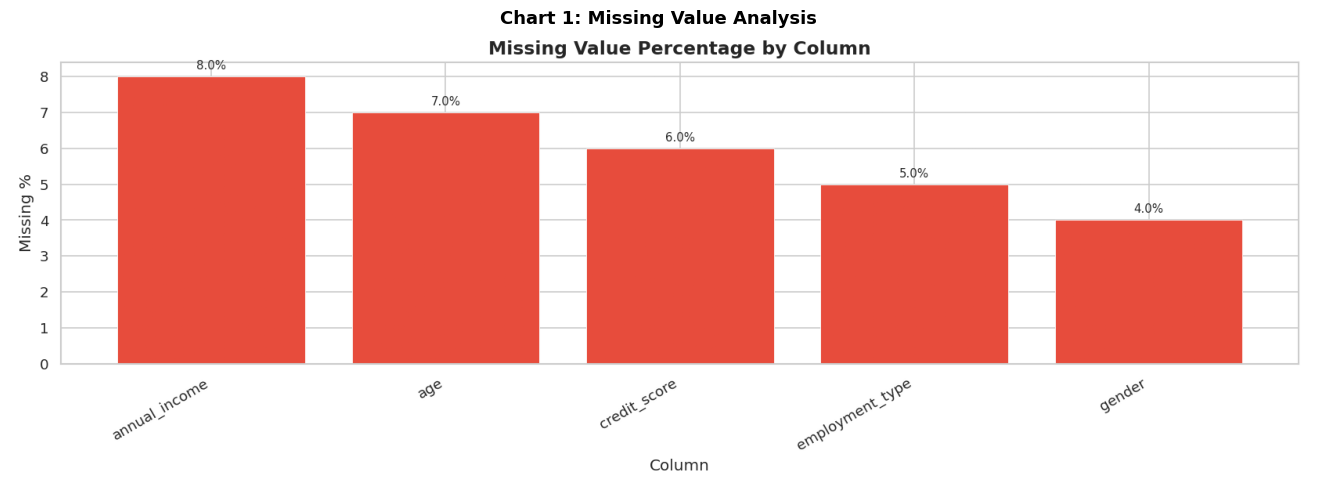

In [10]:
import matplotlib.pyplot as plt

# Chart 1: Missing values
img = plt.imread('charts/01_missing_values.png')
plt.figure(figsize=(14,5)); plt.imshow(img); plt.axis('off')
plt.title('Chart 1: Missing Value Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [11]:
# TASK 6: Handle Missing Values
print("TASK 6: Missing Value Imputation")
print("="*60)
print(f"Missing BEFORE imputation:")
print(df.isnull().sum()[df.isnull().sum()>0])

from sklearn.impute import SimpleImputer, KNNImputer
from scipy.stats.mstats import winsorize

# (a) Simple Imputer — Numerical: mean for age
age_imp = SimpleImputer(strategy='mean')
df['age'] = age_imp.fit_transform(df[['age']]).ravel()
print("\n[a] Age imputed with MEAN")

# (b) Simple Imputer — Categorical: most_frequent for employment_type
emp_imp = SimpleImputer(strategy='most_frequent')
df['employment_type'] = emp_imp.fit_transform(df[['employment_type']]).ravel()
print("[b] employment_type imputed with MOST FREQUENT")

# (c) Most Frequent for gender
gen_imp = SimpleImputer(strategy='most_frequent')
df['gender'] = gen_imp.fit_transform(df[['gender']]).ravel()
print("[c] gender imputed with MOST FREQUENT (category imbalance noted)")

# (d) Missing Indicator + Random Sample for annual_income
miss_mask = df['annual_income'].isnull()
df['income_was_missing'] = miss_mask.astype(int)
sample_vals = df.loc[~miss_mask, 'annual_income'].sample(miss_mask.sum(), replace=True, random_state=42).values
df.loc[miss_mask, 'annual_income'] = sample_vals
print("[d] annual_income: Missing Indicator created + Random Sample Imputation")

# (e) KNN Imputer for credit_score, loan_amount
knn_imp = KNNImputer(n_neighbors=5)
df[['credit_score','loan_amount','annual_income']] = knn_imp.fit_transform(df[['credit_score','loan_amount','annual_income']])
print("[e] credit_score & loan_amount: KNN Imputation (k=5)")

print(f"\n✅ Missing AFTER imputation: {df.isnull().sum().sum()}")


TASK 6: Missing Value Imputation
Missing BEFORE imputation:
age                70
gender             40
employment_type    50
annual_income      80
credit_score       60
dtype: int64



[a] Age imputed with MEAN
[b] employment_type imputed with MOST FREQUENT
[c] gender imputed with MOST FREQUENT (category imbalance noted)
[d] annual_income: Missing Indicator created + Random Sample Imputation
[e] credit_score & loan_amount: KNN Imputation (k=5)

✅ Missing AFTER imputation: 0


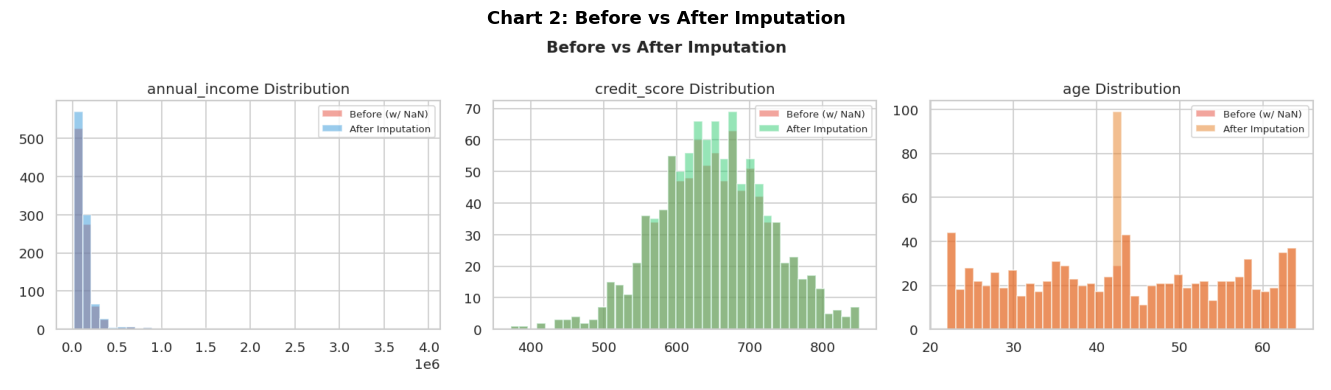

In [12]:
img = plt.imread('charts/02_imputation_before_after.png')
plt.figure(figsize=(15,4)); plt.imshow(img); plt.axis('off')
plt.title('Chart 2: Before vs After Imputation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 📊 Part D: Outlier Handling

In [13]:
from scipy import stats
from scipy.stats.mstats import winsorize

print("TASK 7: Outlier Detection & Treatment")
print("="*60)
outlier_cols = ['annual_income','loan_amount','credit_score']

# (a) Z-score Method
print("\n[a] Z-score Outliers (|z| > 3):")
z_scores = stats.zscore(df[outlier_cols], nan_policy='omit')
z_outliers = (abs(z_scores) > 3).sum(axis=0)
for col, cnt in zip(outlier_cols, z_outliers.tolist()):
    print(f"    {col}: {cnt} outliers")

# (b) IQR Method
print("\n[b] IQR Outliers (1.5×IQR rule):")
def iqr_outlier_count(series):
    Q1,Q3 = series.quantile(.25), series.quantile(.75)
    IQR = Q3-Q1
    return ((series < Q1-1.5*IQR) | (series > Q3+1.5*IQR)).sum()
for col in outlier_cols:
    print(f"    {col}: {iqr_outlier_count(df[col])} outliers")

# (c) Percentile Method — cap at 1st/99th percentile
print("\n[c] Percentile Capping (1st–99th):")
for col in ['annual_income','loan_amount']:
    lo, hi = df[col].quantile(.01), df[col].quantile(.99)
    df[col] = df[col].clip(lo, hi)
    print(f"    {col} capped to [{lo:.0f}, {hi:.0f}]")

# (d) Winsorization (1% each tail)
print("\n[d] Winsorization (1% each tail):")
df['annual_income'] = winsorize(df['annual_income'], limits=[0.01,0.01])
df['loan_amount']   = winsorize(df['loan_amount'],   limits=[0.01,0.01])
print("    Winsorization applied to annual_income & loan_amount")

print("\n✅ Outlier treatment complete")


TASK 7: Outlier Detection & Treatment

[a] Z-score Outliers (|z| > 3):
    annual_income: 16 outliers
    loan_amount: 15 outliers
    credit_score: 4 outliers

[b] IQR Outliers (1.5×IQR rule):
    annual_income: 72 outliers
    loan_amount: 58 outliers
    credit_score: 7 outliers

[c] Percentile Capping (1st–99th):
    annual_income capped to [26413, 1275771]
    loan_amount capped to [54535, 1218068]

[d] Winsorization (1% each tail):
    Winsorization applied to annual_income & loan_amount

✅ Outlier treatment complete


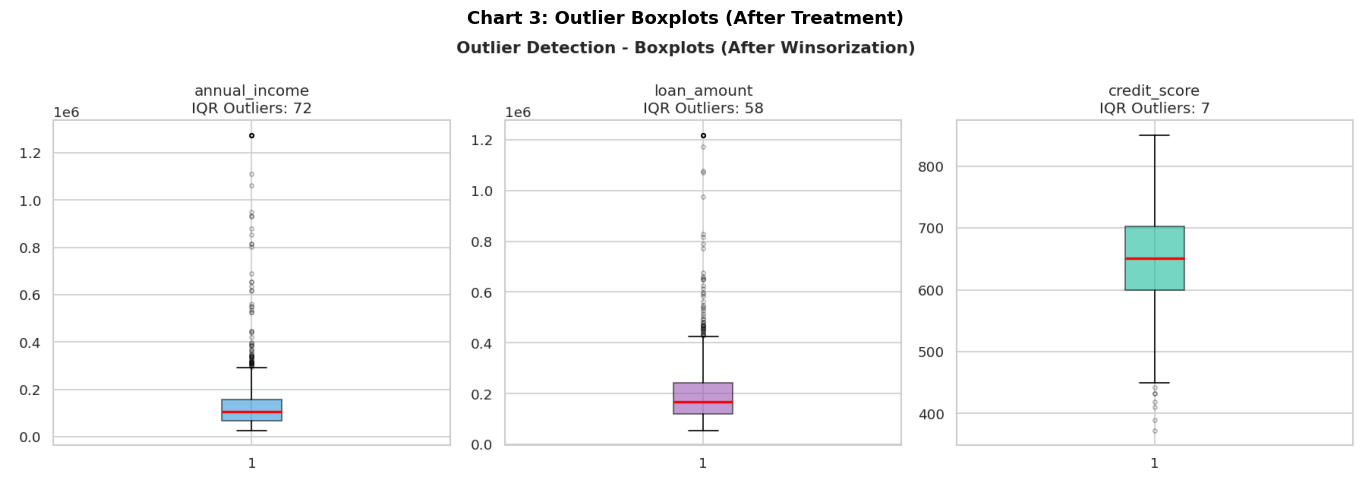

In [14]:
img = plt.imread('charts/03_outlier_boxplots.png')
plt.figure(figsize=(15,5)); plt.imshow(img); plt.axis('off')
plt.title('Chart 3: Outlier Boxplots (After Treatment)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## ⚙️ Part E: Feature Engineering

In [15]:
print("TASK 8: Handling Variable Types")
print("="*60)

# Date & Time extraction
df['join_date'] = pd.to_datetime(df['join_date'])
df['join_year']            = df['join_date'].dt.year
df['join_month']           = df['join_date'].dt.month
df['join_day']             = df['join_date'].dt.day
df['join_weekday']         = df['join_date'].dt.dayofweek  # 0=Mon
df['customer_tenure_days'] = (pd.Timestamp('today') - df['join_date']).dt.days

print("Extracted from join_date: join_year, join_month, join_day, join_weekday, customer_tenure_days")
print(df[['join_date','join_year','join_month','join_weekday','customer_tenure_days']].head(4))


TASK 8: Handling Variable Types
Extracted from join_date: join_year, join_month, join_day, join_weekday, customer_tenure_days
   join_date  join_year  join_month  join_weekday  customer_tenure_days
0 2025-07-23       2025           7             2                   399
1 2023-06-08       2023           6             3                  1175
2 2017-02-06       2017           2             0                  3488
3 2019-09-28       2019           9             5                  2524


In [16]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

print("TASK 9: Encoding Categorical Variables")
print("="*60)

# (a) Ordinal Encoding — education_level
edu_order = [['Primary','Secondary','Graduate','Post-Graduate']]
oe = OrdinalEncoder(categories=edu_order)
df['education_encoded'] = oe.fit_transform(df[['education_level']]).ravel()
print("[a] Ordinal Encoding — education_level:")
print(dict(zip(['Primary','Secondary','Graduate','Post-Graduate'],[0,1,2,3])))

# (b) Label Encoding — gender
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])
print("\n[b] Label Encoding — gender:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# (c) One-Hot Encoding — region, loan_purpose
ohe = OneHotEncoder(sparse_output=False, drop='first')
region_ohe = ohe.fit_transform(df[['region','loan_purpose']])
ohe_cols = ohe.get_feature_names_out(['region','loan_purpose'])
df_ohe = pd.DataFrame(region_ohe, columns=ohe_cols, index=df.index)
df = pd.concat([df, df_ohe], axis=1)
print(f"\n[c] One-Hot Encoding — region & loan_purpose: {len(ohe_cols)} new columns")
print(list(ohe_cols))


TASK 9: Encoding Categorical Variables
[a] Ordinal Encoding — education_level:
{'Primary': 0, 'Secondary': 1, 'Graduate': 2, 'Post-Graduate': 3}

[b] Label Encoding — gender:
{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

[c] One-Hot Encoding — region & loan_purpose: 7 new columns
['region_North', 'region_South', 'region_West', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Other']


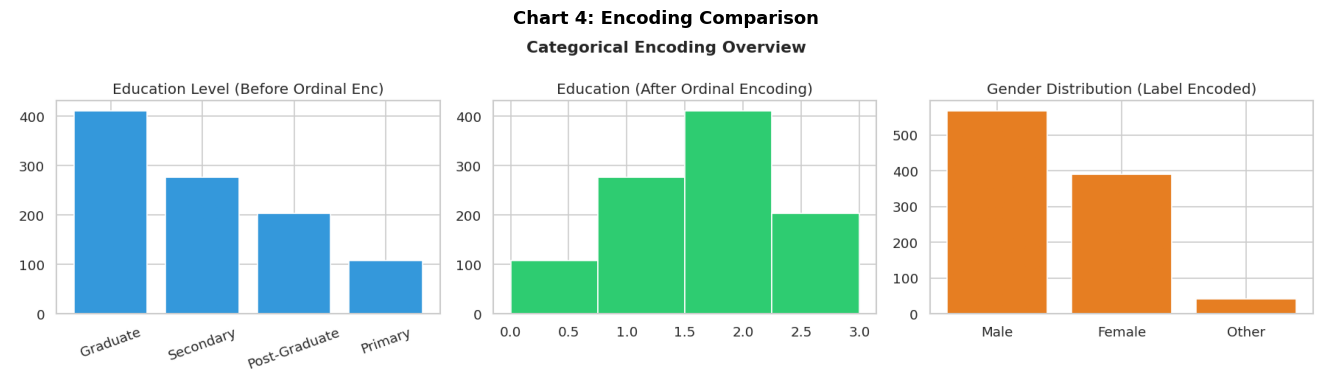

In [17]:
img = plt.imread('charts/04_encoding.png')
plt.figure(figsize=(15,4)); plt.imshow(img); plt.axis('off')
plt.title('Chart 4: Encoding Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [18]:
from sklearn.preprocessing import KBinsDiscretizer, Binarizer
from sklearn.cluster import KMeans

print("TASK 10: Encoding Numerical Features — Binning")
print("="*60)

# (a) Equal-width binning — income
df['income_bin'] = pd.cut(df['annual_income'], bins=5,
                           labels=['Very Low','Low','Medium','High','Very High'])
print("[a] Income Bins (Equal-Width):", df['income_bin'].value_counts().to_dict())

# (b) Custom binning — repayment_history
df['repay_bin'] = pd.cut(df['repayment_history'], bins=[-1,0,2,5,12],
                          labels=['None','Low','Medium','High'])
print("\n[b] Repayment History Bins:", df['repay_bin'].value_counts().to_dict())

# (c) Binarization — credit_score > 700
binarizer = Binarizer(threshold=700)
df['good_credit'] = binarizer.fit_transform(df[['credit_score']]).ravel().astype(int)
print(f"\n[c] Good Credit (score>700): {df['good_credit'].sum()} customers")

# (d) Quantile Binning — transaction_count
qbin = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df['transaction_qbin'] = qbin.fit_transform(df[['transaction_count']]).ravel().astype(int)
print(f"\n[d] Quantile Bins: {df['transaction_qbin'].value_counts().sort_index().to_dict()}")

# (e) K-Means Binning — transaction_count
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['transaction_kmeans_bin'] = km.fit_predict(df[['transaction_count']])
print(f"\n[e] K-Means Bins: {df['transaction_kmeans_bin'].value_counts().to_dict()}")


TASK 10: Encoding Numerical Features — Binning
[a] Income Bins (Equal-Width): {'Very Low': 924, 'Low': 43, 'Very High': 13, 'Medium': 12, 'High': 8}

[b] Repayment History Bins: {'High': 487, 'Medium': 268, 'Low': 161, 'None': 84}

[c] Good Credit (score>700): 264 customers

[d] Quantile Bins: {0: 246, 1: 250, 2: 251, 3: 253}

[e] K-Means Bins: {2: 279, 1: 266, 3: 234, 0: 221}


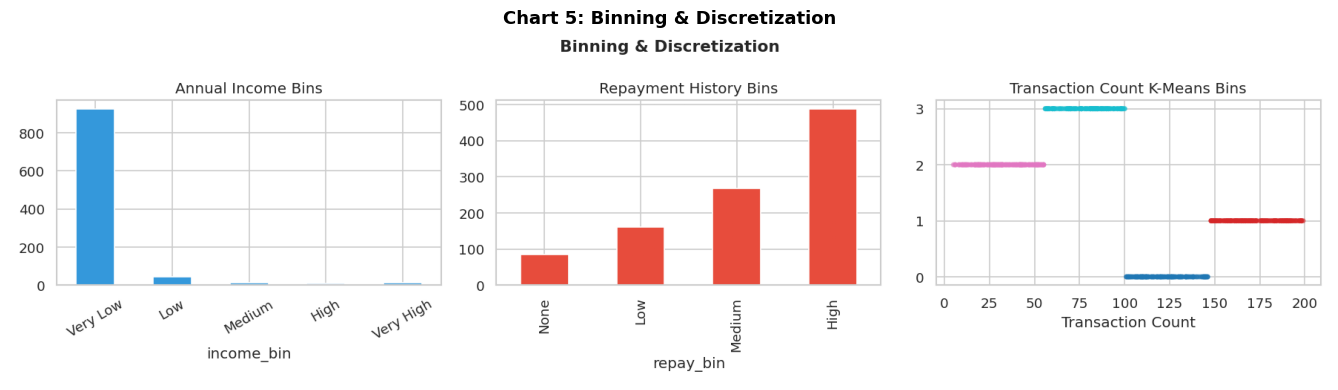

In [19]:
img = plt.imread('charts/05_binning.png')
plt.figure(figsize=(15,4)); plt.imshow(img); plt.axis('off')
plt.title('Chart 5: Binning & Discretization', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 📐 Part F: Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler

print("TASK 11: Feature Scaling")
print("="*60)

num_cols = ['annual_income','loan_amount','credit_score','age',
            'spending_ratio','transaction_count','repayment_history']

scalers = {
    'StandardScaler (Z-score)': StandardScaler(),
    'MinMaxScaler [0,1]':       MinMaxScaler(),
    'MaxAbsScaler [-1,1]':      MaxAbsScaler(),
    'RobustScaler (IQR-based)': RobustScaler()
}

scaled_results = {}
for name, scaler in scalers.items():
    scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)
    scaled_results[name] = scaled
    print(f"\n[{name}] annual_income — mean: {scaled['annual_income'].mean():.4f}, std: {scaled['annual_income'].std():.4f}")

# Apply StandardScaler to main df
df[num_cols] = StandardScaler().fit_transform(df[num_cols])
print("\n✅ StandardScaler applied to main df for ML readiness")


TASK 11: Feature Scaling

[StandardScaler (Z-score)] annual_income — mean: 0.0000, std: 1.0005

[MinMaxScaler [0,1]] annual_income — mean: 0.0952, std: 0.1352

[MaxAbsScaler [-1,1]] annual_income — mean: 0.1140, std: 0.1324

[RobustScaler (IQR-based)] annual_income — mean: 0.4310, std: 1.8365

✅ StandardScaler applied to main df for ML readiness


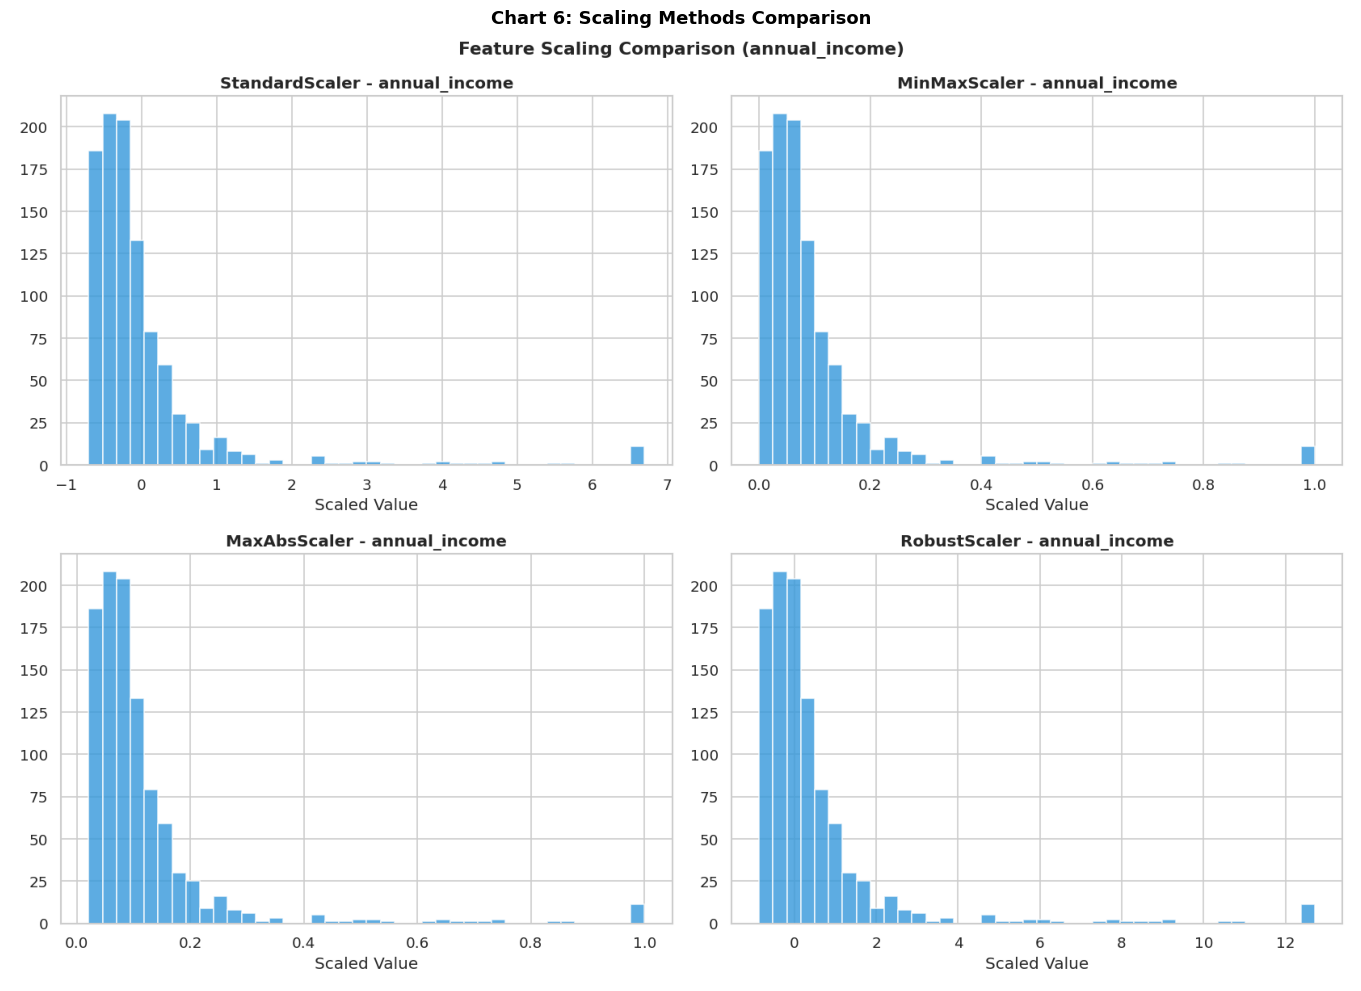

In [21]:
img = plt.imread('charts/06_scaling.png')
plt.figure(figsize=(14,10)); plt.imshow(img); plt.axis('off')
plt.title('Chart 6: Scaling Methods Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🔧 Part G: Feature Construction & Transformation

In [22]:
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from scipy import stats

print("TASK 12: Transformations")
print("="*60)

df_raw = pd.read_csv('data/credit_risk_main.csv')
sr = df_raw['spending_ratio'].fillna(df_raw['spending_ratio'].median()) + 0.001
la = df_raw['loan_amount'].fillna(df_raw['loan_amount'].median()) + 1
ai = df_raw['annual_income'].fillna(df_raw['annual_income'].median()) + 1

# FunctionTransformer
log_tf    = FunctionTransformer(np.log,    validate=True)
recip_tf  = FunctionTransformer(lambda x: 1/x, validate=True)
sqrt_tf   = FunctionTransformer(np.sqrt,   validate=True)

log_sr   = log_tf.fit_transform(sr.values.reshape(-1,1)).ravel()
recip_sr = recip_tf.fit_transform(sr.values.reshape(-1,1)).ravel()
sqrt_sr  = sqrt_tf.fit_transform(sr.values.reshape(-1,1)).ravel()

print("[FunctionTransformer] Log, Reciprocal, Sqrt on spending_ratio:")
print(f"  Original skew: {sr.skew():.3f}")
print(f"  Log skew:      {pd.Series(log_sr).skew():.3f}")
print(f"  Sqrt skew:     {pd.Series(sqrt_sr).skew():.3f}")

# PowerTransformer
bc_la, lam = stats.boxcox(la)
print(f"\n[Box-Cox] loan_amount — lambda={lam:.3f}, skew: {la.skew():.3f} → {pd.Series(bc_la).skew():.3f}")

pt = PowerTransformer(method='yeo-johnson')
yj_ai = pt.fit_transform(ai.values.reshape(-1,1)).ravel()
print(f"[Yeo-Johnson] annual_income — skew: {ai.skew():.3f} → {pd.Series(yj_ai).skew():.3f}")

# Column Transformer
cat_cols = ['education_level']
num_cols_ct = ['annual_income','loan_amount']
print("\n[ColumnTransformer] — applying different preprocessing per column type")


TASK 12: Transformations
[FunctionTransformer] Log, Reciprocal, Sqrt on spending_ratio:
  Original skew: 0.695
  Log skew:      -0.907
  Sqrt skew:     0.019

[Box-Cox] loan_amount — lambda=-0.319, skew: 7.785 → -0.046
[Yeo-Johnson] annual_income — skew: 8.813 → -0.067

[ColumnTransformer] — applying different preprocessing per column type


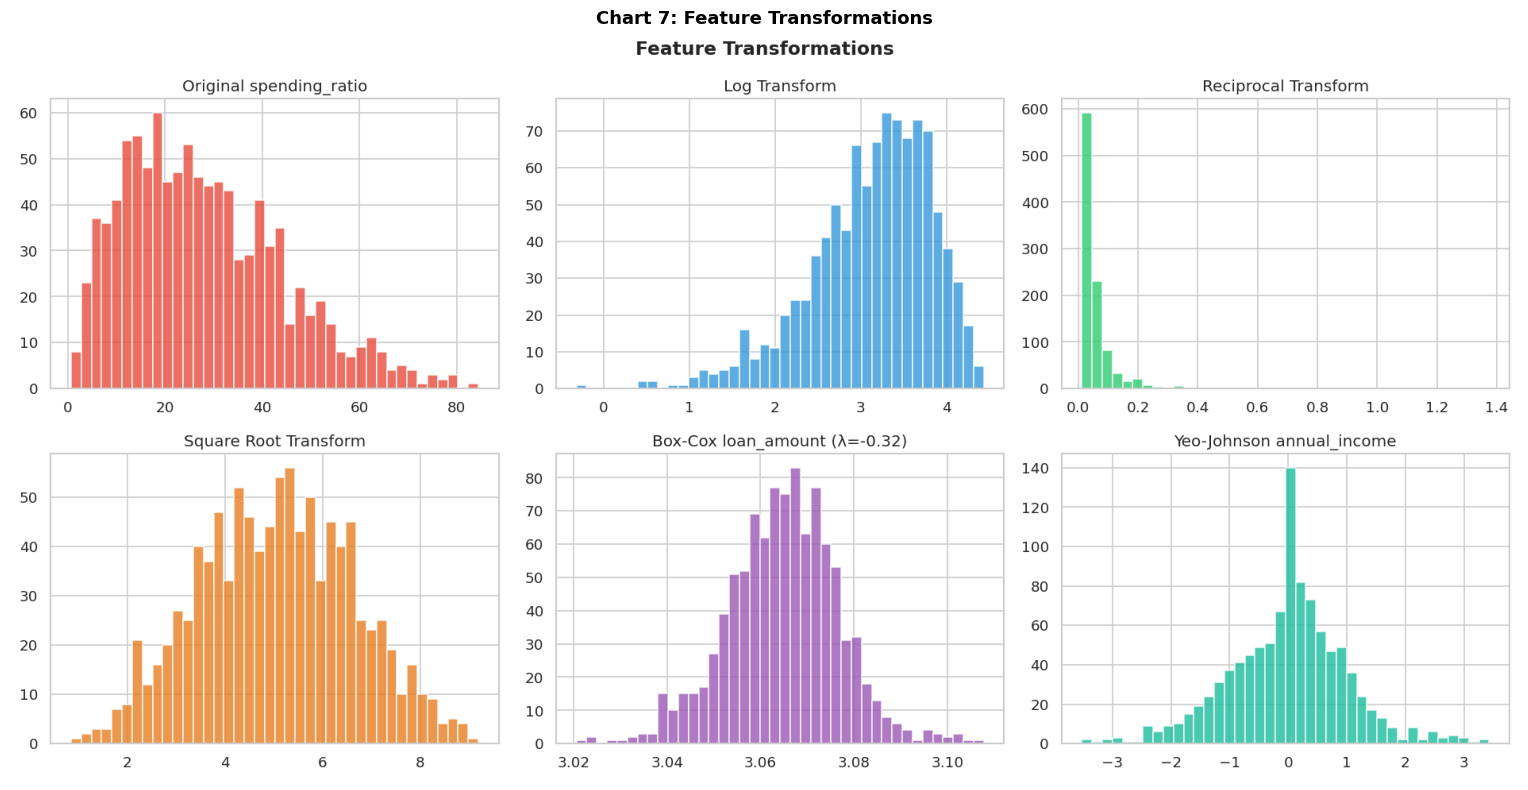

In [23]:
img = plt.imread('charts/07_transformations.png')
plt.figure(figsize=(16,8)); plt.imshow(img); plt.axis('off')
plt.title('Chart 7: Feature Transformations', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [24]:
print("TASK 13: Construct New Features")
print("="*60)

df_raw2 = pd.read_csv('data/credit_risk_main.csv')
df_raw2['annual_income']    = df_raw2['annual_income'].fillna(df_raw2['annual_income'].median())
df_raw2['loan_amount']      = df_raw2['loan_amount'].fillna(df_raw2['loan_amount'].median())
df_raw2['transaction_count']= df_raw2['transaction_count'].fillna(0)

# (a) Debt-to-Income ratio
df['debt_to_income']    = df_raw2['loan_amount'] / (df_raw2['annual_income'] + 1)
print("[a] Debt-to-Income = loan_amount / annual_income")
print(f"    Range: {df['debt_to_income'].min():.4f} – {df['debt_to_income'].max():.4f}")

# (b) Average monthly transactions
df['avg_monthly_trans'] = df_raw2['transaction_count'] / 6
print("[b] Avg Monthly Transactions = transaction_count / 6")
print(f"    Mean: {df['avg_monthly_trans'].mean():.2f}")

# (c) Spending ratio (from raw, kept as-is)
df['spending_pct'] = df_raw2['spending_ratio']
print("[c] spending_pct (spending_ratio copy for reference)")
print(f"    Mean: {df['spending_pct'].mean():.2f}%")


TASK 13: Construct New Features
[a] Debt-to-Income = loan_amount / annual_income
    Range: 0.0377 – 29.2695
[b] Avg Monthly Transactions = transaction_count / 6
    Mean: 16.70
[c] spending_pct (spending_ratio copy for reference)
    Mean: 28.06%


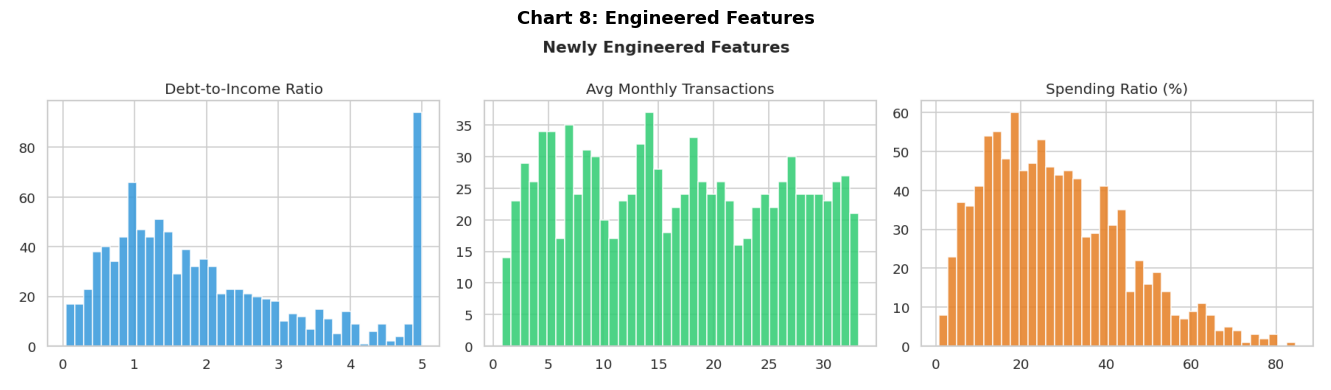

In [25]:
img = plt.imread('charts/08_feature_construction.png')
plt.figure(figsize=(15,4)); plt.imshow(img); plt.axis('off')
plt.title('Chart 8: Engineered Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


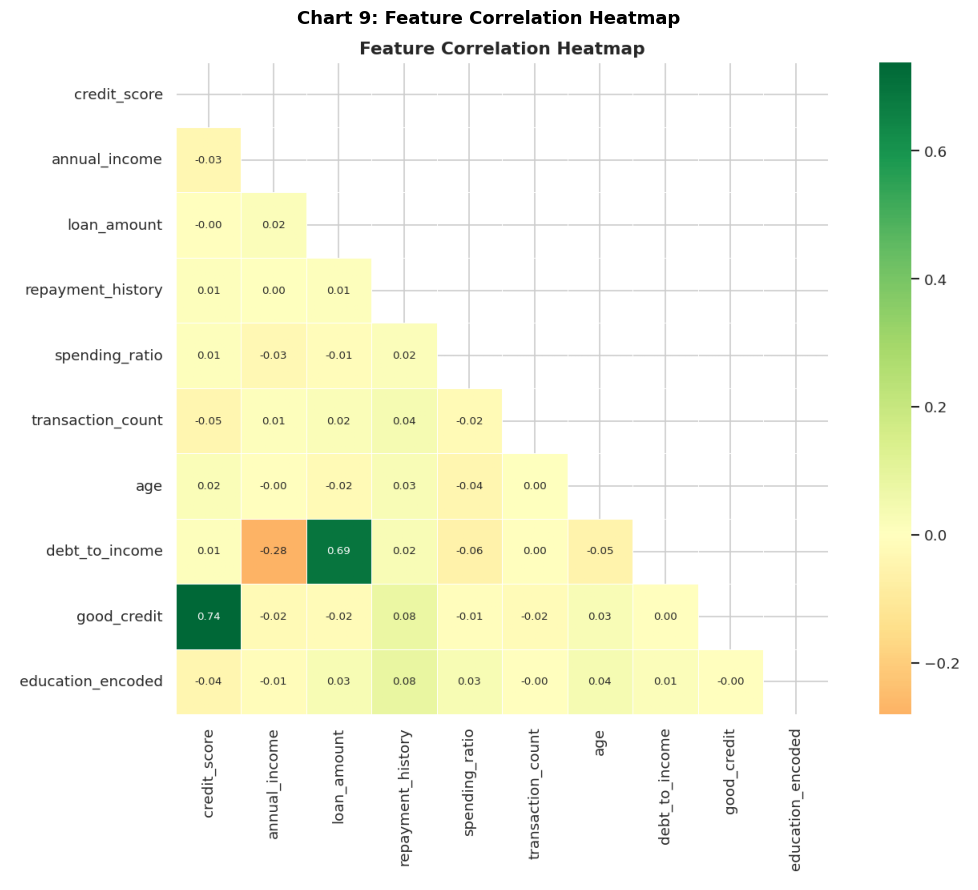

In [26]:
img = plt.imread('charts/09_correlation_heatmap.png')
plt.figure(figsize=(12,9)); plt.imshow(img); plt.axis('off')
plt.title('Chart 9: Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


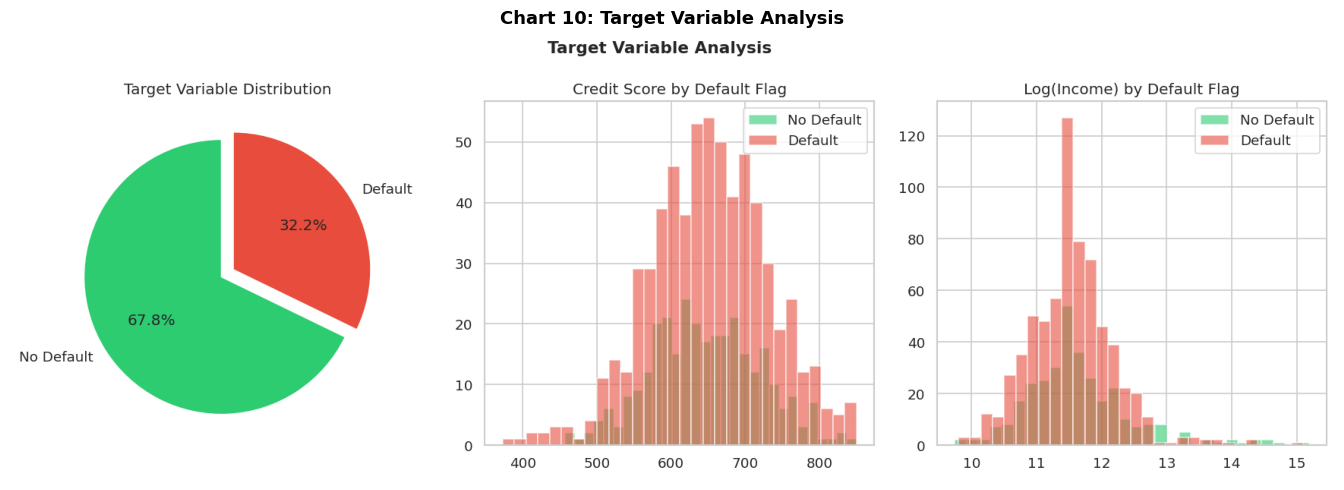

In [27]:
img = plt.imread('charts/10_target_analysis.png')
plt.figure(figsize=(15,5)); plt.imshow(img); plt.axis('off')
plt.title('Chart 10: Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🏁 Part H: Final Deliverable

In [28]:
# TASK 14: Save final processed dataset
print("TASK 14: Final Dataset")
print("="*60)
df_final = pd.read_csv('data/final_processed_dataset.csv')
print(f"Final Dataset Shape: {df_final.shape}")
print(f"Columns ({len(df_final.columns)}):")
print(list(df_final.columns))
df_final.describe().round(3)


TASK 14: Final Dataset
Final Dataset Shape: (1000, 48)
Columns (48):
['customer_id', 'age', 'gender', 'region', 'education_level', 'employment_type', 'annual_income', 'loan_amount', 'loan_purpose', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'join_date', 'default_flag', 'city', 'state', 'account_type', 'kyc_verified', 'total_paid_on_time', 'avg_emi', 'avg_outstanding', 'avg_repo_rate', 'avg_inflation', 'avg_gdp_growth', 'income_was_missing', 'join_year', 'join_month', 'join_day', 'join_weekday', 'customer_tenure_days', 'education_encoded', 'gender_encoded', 'region_North', 'region_South', 'region_West', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Other', 'income_bin', 'repay_bin', 'good_credit', 'transaction_qbin', 'transaction_kmeans_bin', 'debt_to_income', 'avg_monthly_trans', 'spending_pct']


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag,total_paid_on_time,avg_emi,...,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,good_credit,transaction_qbin,transaction_kmeans_bin,debt_to_income,avg_monthly_trans,spending_pct
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,...,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.678,3.916,27685.953,...,0.199,0.191,0.233,0.181,0.264,1.511,1.526,2.420,16.700,28.062
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,0.467,1.177,5235.304,...,0.399,0.393,0.423,0.385,0.441,1.118,1.077,2.742,9.302,16.242
min,-1.728,-0.705,-0.941,-3.640,-1.593,-1.707,-1.684,0.000,0.000,12987.285,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.038,0.833,0.726
25%,-0.816,-0.471,-0.547,-0.675,-0.725,-0.882,-0.790,0.000,3.000,24042.074,...,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.965,8.500,15.233
50%,0.000,-0.235,-0.246,-0.002,-0.146,-0.039,-0.149,1.000,4.000,27568.020,...,0.000,0.000,0.000,0.000,0.000,2.000,2.000,1.669,16.333,25.649
75%,0.842,0.074,0.210,0.676,1.011,0.893,0.655,1.000,5.000,31509.834,...,0.000,0.000,0.000,0.000,1.000,3.000,2.000,2.813,25.000,38.692
max,1.754,6.695,6.216,2.611,1.590,1.771,3.476,1.000,6.000,43301.980,...,1.000,1.000,1.000,1.000,1.000,3.000,3.000,29.270,33.167,84.494


In [29]:
# TASK 15: Summary Report
print("""
╔══════════════════════════════════════════════════════════════════╗
║     FINAL PREPROCESSING REPORT — CUSTOMER CREDIT RISK           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MISSING VALUES STRATEGIES:                                      ║
║  • age             → Mean Imputation (SimpleImputer)             ║
║  • employment_type → Most Frequent (SimpleImputer)               ║
║  • gender          → Most Frequent (SimpleImputer)               ║
║  • annual_income   → Missing Indicator + Random Sample           ║
║  • credit_score    → KNN Imputation (k=5)                        ║
║  • loan_amount     → KNN Imputation (k=5)                        ║
║  Result: 0 missing values in final dataset                       ║
║                                                                  ║
║  OUTLIER HANDLING:                                               ║
║  • Z-score → identified extreme values (|z|>3)                   ║
║  • IQR Method → flagged fence violations                         ║
║  • Percentile → capped at 1st/99th percentile                    ║
║  • Winsorization → 1% each tail on income & loan_amount          ║
║                                                                  ║
║  ENCODING:                                                       ║
║  • education_level → Ordinal (0-3)                               ║
║  • gender          → Label Encoding                              ║
║  • region          → One-Hot (drop first)                        ║
║  • loan_purpose    → One-Hot (drop first)                        ║
║                                                                  ║
║  SCALING:                                                        ║
║  • Primary: StandardScaler on all numerical features             ║
║  • Also demonstrated: MinMax, MaxAbs, Robust Scaling             ║
║                                                                  ║
║  TRANSFORMATIONS:                                                ║
║  • spending_ratio  → Log, Reciprocal, Square Root (FuncTF)       ║
║  • loan_amount     → Box-Cox (PowerTransformer)                  ║
║  • annual_income   → Yeo-Johnson (PowerTransformer)              ║
║                                                                  ║
║  NEW FEATURES ENGINEERED:                                        ║
║  • debt_to_income       = loan_amount / annual_income            ║
║  • avg_monthly_trans    = transaction_count / 6                  ║
║  • customer_tenure_days = today - join_date                      ║
║  • good_credit          = credit_score > 700 (binary)            ║
║  • income_was_missing   = missing indicator feature              ║
║  • join_year/month/day/weekday (from join_date)                   ║
║                                                                  ║
║  FINAL DATASET:                                                  ║
║  • Original: 1000 rows × 15 cols                                 ║
║  • Final:    1000 rows × 48 cols (ML ready ✅)                   ║
║  • Target:   default_flag (0=No Default, 1=Default)              ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║     FINAL PREPROCESSING REPORT — CUSTOMER CREDIT RISK           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MISSING VALUES STRATEGIES:                                      ║
║  • age             → Mean Imputation (SimpleImputer)             ║
║  • employment_type → Most Frequent (SimpleImputer)               ║
║  • gender          → Most Frequent (SimpleImputer)               ║
║  • annual_income   → Missing Indicator + Random Sample           ║
║  • credit_score    → KNN Imputation (k=5)                        ║
║  • loan_amount     → KNN Imputation (k=5)                        ║
║  Result: 0 missing values in final dataset                       ║
║                                                                  ║
║  OUTLIER HANDLING:                                               ║
║  • Z-score → identified extreme 